# US 7,557,996 B2 — projection objective construction and imaging

**Canonical embodiment:** Figure 3, Tables 3 and 3A.
**Operating point:** $\lambda=193.368$ nm, image-side NA = 1.2, nominal 4× reduction.

This notebook replicates the reference `patent_objective` analysis on the
`raytracer` API:

1. load the complete patent prescription from the packaged CSV;
2. validate the even-asphere surface equation;
3. trace rays by exact Newton intersection, vector Snell refraction, and reflection;
4. draw the closed lens layout and folded ray path;
5. verify conjugates, magnification, clear apertures, and numerical aperture;
6. measure spots, aberrations, and the ANSI/OSA Zernike wavefront;
7. form the scalar PSF and a partially coherent Abbe aerial image.

## 0 · Imports

All prescription dimensions are millimetres. Requires NumPy, SciPy, and Matplotlib.

In [1]:
from importlib import resources
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from raytracer.design import OpticalSystem
from raytracer.propagation import (
    FieldPoint,
    ParaxialModel,
    PupilSampling,
    SequentialTracer,
    chief_ray_slope,
    differential_conjugates,
    solve_object_plane,
    trace_from_object,
    trace_pupil,
)
from raytracer.analysis import (
    BinaryMask, abbe_image, airy_radius_mm, field_metrics, fit_transverse,
    pupil_function, ray_fans, scalar_psf, spot_data,
)
from raytracer.viz import plots

NA_IMAGE, REDUCTION = 1.2, 4.0
NA_OBJECT = NA_IMAGE / REDUCTION
FIELDS = [56.0, 62.0, 67.0]

CSV = resources.files("raytracer").parent / "data" / "optical_systems/lithography/US7557996_Fig3_Table3_prescription.csv"
system = OpticalSystem.from_prescription(CSV)
tracer = SequentialTracer(system)
WAVELENGTH_MM = system.wavelength_um * 1e-3

OUT = Path("outputs_us7557996"); OUT.mkdir(exist_ok=True)
print(f"{len(system)} sequential surfaces, stop at index {system.stop_index}")
print(f"Image plane z = {system.image_z:.6f} mm, image-space index {system.n_image}")

48 sequential surfaces, stop at index 34
Image plane z = 1423.077700 mm, image-space index 1.59667693


## 1 · Patent prescription

Each row carries the surface radius, signed axial distance to the next
surface, medium, refractive index at 193.368 nm, and clear semidiameter.
Negative thicknesses after M1 describe the reflected return path. The
asphere sag is

$$z(h)=\frac{c h^2}{1+\sqrt{1-(1+K)c^2h^2}}+\sum_{j=1}^{6} C_j h^{2j+2},\qquad c=1/R.$$

In [2]:
header = f"{'surface':>8} {'kind':>14} {'radius_mm':>16} {'thickness':>13} "
header += f"{'material':>10} {'index':>11} {'semidiam':>9} {'aspheric':>9}"
print(header); print("-" * len(header))
for i, row in enumerate(system.rows, 1):
    material = "REFL" if row.reflective else row.material_after.name
    aspheric = bool(row.profile.coefficients)
    print(f"{i:>8} {row.kind.value:>14} {row.radius:>16.6f} {row.thickness:>13.6f} "
          f"{material:>10} {system.n_after[i-1]:>11.8f} "
          f"{row.semidiameter:>9.3f} {str(aspheric):>9}")

 surface           kind        radius_mm     thickness   material       index  semidiam  aspheric
-------------------------------------------------------------------------------------------------
       1     refractive      -404.542022     36.232225       SIO2  1.56078570    88.996     False
       2     refractive      -184.402723      1.000090        AIR  1.00000000    95.088      True
       3     refractive       674.592973     51.347982       SIO2  1.56078570   102.076     False
       4     refractive      -174.232362    144.581202        AIR  1.00000000   102.829     False
       5     refractive      -162.800929     14.999049       CAF2  1.50185255    53.189      True
       6     refractive     -1456.920767     15.293417        AIR  1.00000000    63.896     False
       7         mirror      -202.841004    -15.293417       REFL  1.00000000    67.884     False
       8     refractive     -1456.920767    -14.999049       CAF2  1.50185255    67.836     False
       9     refract

## 2 · Surface mathematics

The analytic sag slope must agree with a centred finite difference — this is
the derivative the Newton intersection and the surface normals rely on.

Maximum sag (mm): 16.43938618233247
Interior slope discrepancy: 1.5085150028015804e-06


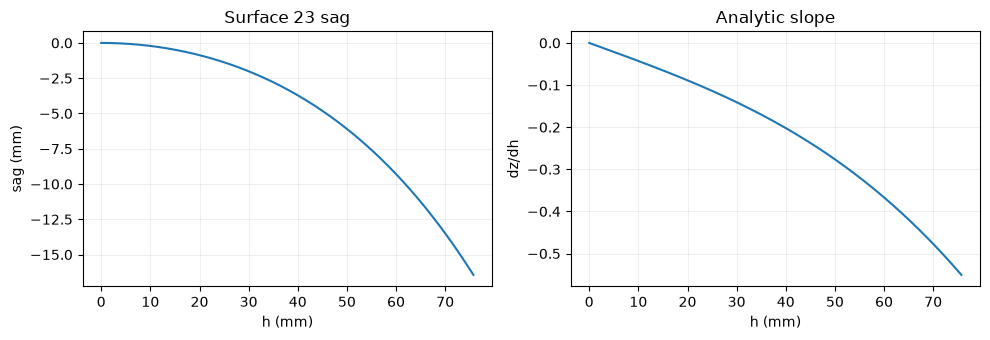

In [3]:
surface = system.rows[22]  # patent surface 23, aspheric
h = np.linspace(0, 0.9 * surface.semidiameter, 400)
sag, slope = surface.profile.sag_and_slope(h)
numeric = np.gradient(sag, h)
print("Maximum sag (mm):", float(np.max(np.abs(sag))))
print("Interior slope discrepancy:", float(np.max(np.abs(slope[2:-2] - numeric[2:-2]))))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(h, sag); axes[0].set(xlabel="h (mm)", ylabel="sag (mm)", title="Surface 23 sag")
axes[1].plot(h, slope); axes[1].set(xlabel="h (mm)", ylabel="dz/dh", title="Analytic slope")
for ax in axes: ax.grid(alpha=0.2)
fig.tight_layout(); plt.show()

## 3 · Conjugate recovery and first-order validation

Table 3 does not list the object-plane separation: it is recovered by
imposing $B=0$ at the tabulated image plane, once with differential rays
through the exact tracer and once with the analytic paraxial ABCD matrix.
The transverse magnification must be +0.25 (net upright 4× reduction).

In [4]:
solution = solve_object_plane(tracer)  # assigns system.object_z
matrix = ParaxialModel(system).solve_object_plane()
print(f"Differential rays : z_obj = {solution.object_z:.9f} mm, M = {solution.magnification:.10f}")
print(f"Paraxial matrix   : z_obj = {matrix.object_z:.9f} mm, M = {matrix.magnification:.10f}")
assert abs(solution.magnification - 0.25) < 2e-7

for object_y in FIELDS:
    sy = chief_ray_slope(tracer, FieldPoint(y=object_y))
    result = trace_from_object(tracer, (0.0, object_y), (0.0, sy))
    print(f"object y={object_y:5.1f} mm -> image y={result.image_point[1]:9.6f} mm, "
          f"chief slope={sy:+.7f}")

Differential rays : z_obj = -76.876406191 mm, M = 0.2500000135
Paraxial matrix   : z_obj = -76.876407190 mm, M = 0.2500000135
object y= 56.0 mm -> image y=14.000000 mm, chief slope=-0.0018425
object y= 62.0 mm -> image y=15.499997 mm, chief slope=-0.0031983


object y= 67.0 mm -> image y=16.749999 mm, chief slope=-0.0048404


## 4 · Closed-form optical layout and ray trace

Each lens is closed with both optical faces and its rim edges; fused silica,
CaF₂, and the final high-index element fill separately, and the high-index
immersion layer is shaded at the wafer end. The thick black curves are M1 and M2.

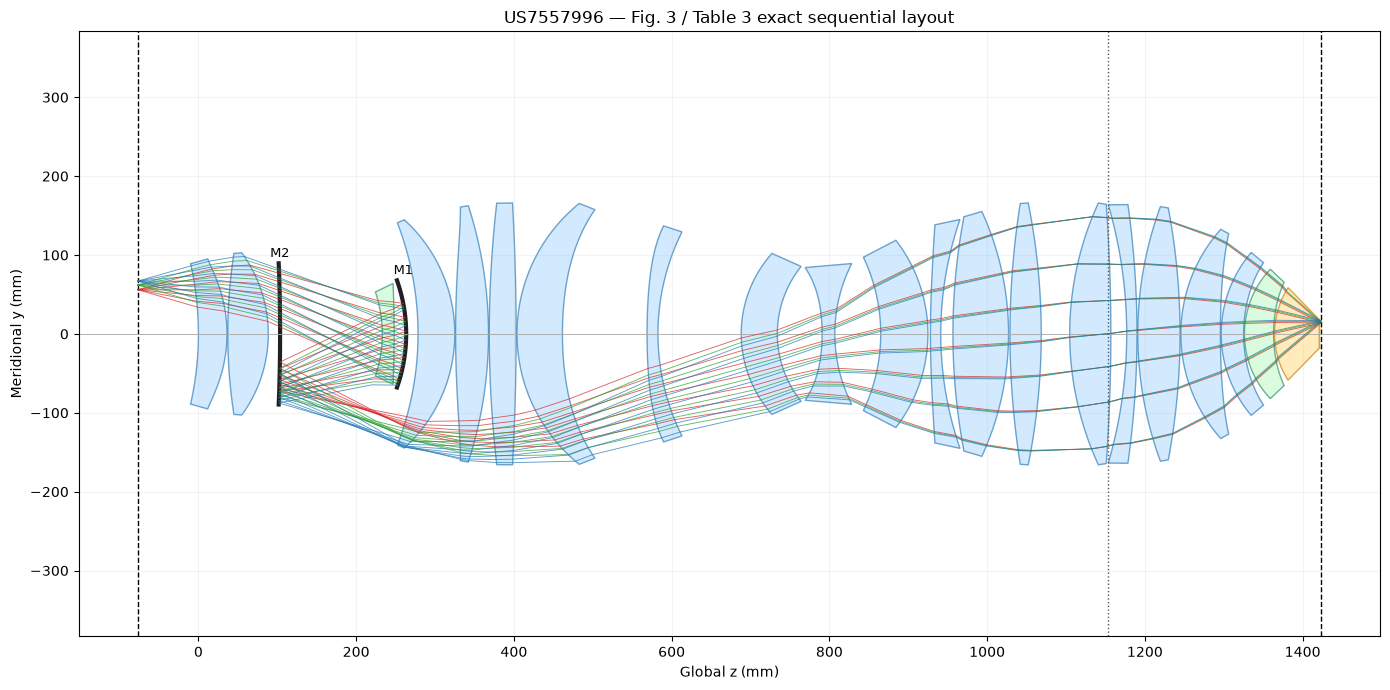

In [5]:
fig = plots.layout_figure(
    tracer, fields=FIELDS, fan_half_slope=0.29, fan_count=7,
    title="US7557996 — Fig. 3 / Table 3 exact sequential layout",
)
fig.savefig(OUT / "layout_raytrace.png", dpi=180)
plt.show()

## 5 · Pupil coverage and numerical aperture

The nominal object-space sine is $1.2/4=0.3$. Rays sample this circular
pupil and are rejected only when a patent clear aperture clips them.
Image-space NA is $n\sqrt{d_x^2+d_y^2}$ in the final medium.

Unvignetted rays: 754
Maximum traced image-space NA: 1.197703


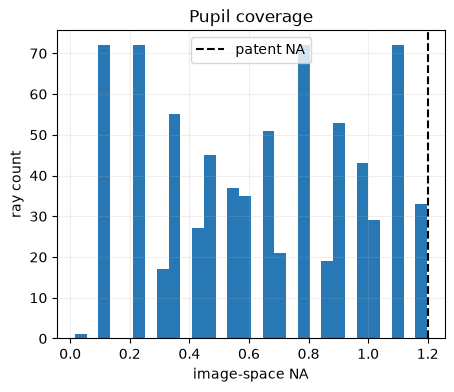

In [6]:
pupil = trace_pupil(
    tracer, FieldPoint(y=62.0), na_object_sine=NA_OBJECT,
    sampling=PupilSampling(kind="rings", radial=12, azimuth=72),
)
image_na = system.n_image * np.hypot(pupil.directions[:, 0], pupil.directions[:, 1])
print("Unvignetted rays:", int(pupil.valid.sum()))
print(f"Maximum traced image-space NA: {image_na.max():.6f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(image_na, bins=30, color="#2878b5")
ax.axvline(NA_IMAGE, color="black", ls="--", label="patent NA")
ax.set(xlabel="image-space NA", ylabel="ray count", title="Pupil coverage")
ax.legend(); ax.grid(alpha=0.2); plt.show()

## 6 · Geometric image quality

Spot plots use exact non-paraxial rays at three positions in the annular
object field, recentred at the area-weighted image centroid.

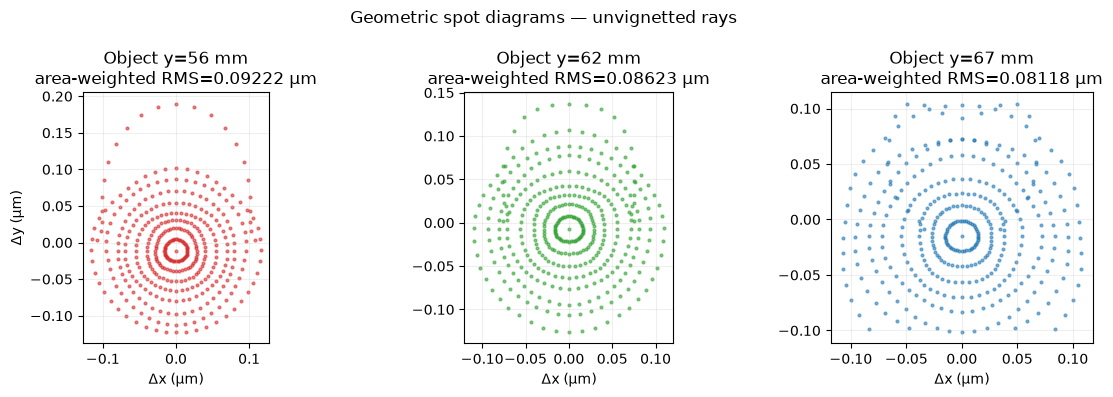

In [7]:
spots = [
    spot_data(trace_pupil(tracer, FieldPoint(y=y), na_object_sine=NA_OBJECT,
                          sampling=PupilSampling(kind="rings", radial=10, azimuth=48)))
    for y in FIELDS
]
# Same per-field palette the layout rays use (plots.FIELD_COLORS order).
fig = plots.spots_figure(spots, colors=plots.FIELD_COLORS[:len(spots)])
fig.savefig(OUT / "spot_diagrams.png", dpi=180)
plt.show()

## 7 · Monochromatic aberration measurements

Area-weighted RMS spot errors, EE80, centroid distortion against the 4×
paraxial image, sagittal/tangential best-focus shifts, astigmatic
separation, and transverse ray-aberration fans — all from exact rays.

      image y (mm) |           RMS (µm) |      best RMS (µm) |          EE80 (µm) |    distortion (µm) | chief distortion (µm) |    S focus Δz (mm) |    T focus Δz (mm) |           T−S (mm)
         14.000011 |        0.092218766 |        0.012736099 |         0.11107446 |        0.010783338 |     -0.00024942126 |     -0.00012421923 |     -0.00013583882 |      -1.161959e-05
         15.500005 |        0.086225812 |        0.014922366 |         0.10534665 |       0.0051072266 |      -0.0026817908 |      -0.0001156703 |     -0.00012617838 |     -1.0508084e-05
         16.750014 |        0.081181224 |        0.020834862 |         0.10324211 |        0.014383354 |     -0.00082363846 |     -0.00011056055 |     -0.00012247998 |     -1.1919436e-05


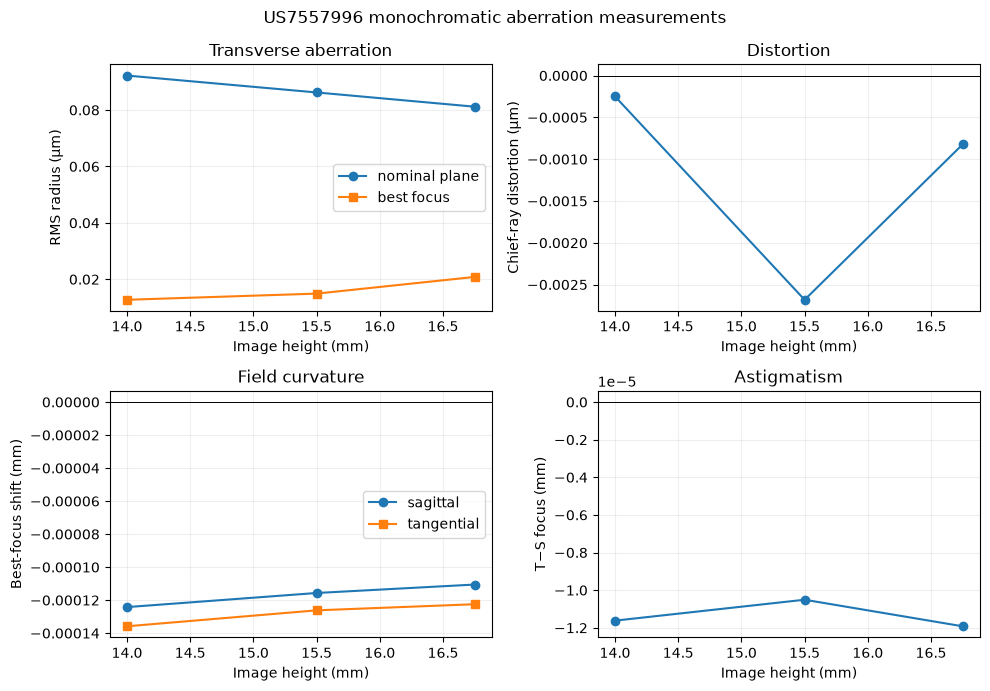

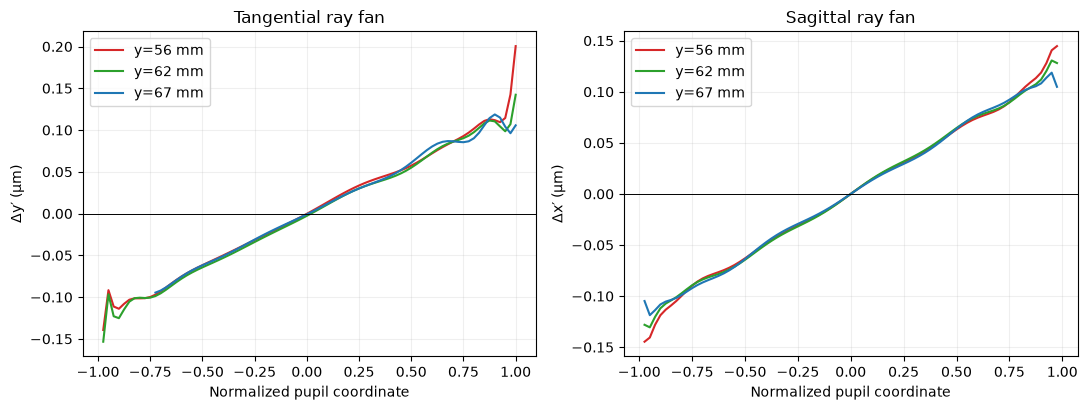

In [8]:
metrics = field_metrics(
    tracer, FIELDS, na_object_sine=NA_OBJECT, magnification=1.0 / REDUCTION,
)

header = ("image y (mm)", "RMS (µm)", "best RMS (µm)", "EE80 (µm)", "distortion (µm)",
          "chief distortion (µm)", "S focus Δz (mm)", "T focus Δz (mm)", "T−S (mm)")
print(" | ".join(f"{item:>18}" for item in header))
for row in metrics:
    values = (row["centroid_image_height_mm"], row["rms_spot_radius_um"],
              row["best_focus_rms_spot_um"], row["ee80_radius_um"], row["distortion_um"],
              row["chief_ray_distortion_um"],
              row["sagittal_focus_shift_mm"], row["tangential_focus_shift_mm"],
              row["astigmatic_separation_mm"])
    print(" | ".join(f"{v:>18.8g}" for v in values))

fig = plots.aberrations_figure(metrics, suptitle="US7557996 monochromatic aberration measurements")
fig.savefig(OUT / "aberration_summary.png", dpi=180); plt.show()

fans = [ray_fans(tracer, FieldPoint(y=y), na_object_sine=NA_OBJECT,
                 magnification=1.0 / REDUCTION) for y in FIELDS]
fig = plots.fans_figure(fans)
fig.savefig(OUT / "ray_aberration_fans.png", dpi=180); plt.show()


### 7b · Dense distortion curve and distortion grid

The three-field table above doubles as the aberration summary for the
whole notebook, so it stays at the patent's three reference field
points. For distortion specifically, a few points understate what the
metric is actually doing — here it is resampled densely across the full
0-67 mm object field, plus the classic warped-grid display used in
optical design software (a square grid of field points, traced and shown
at the image plane).

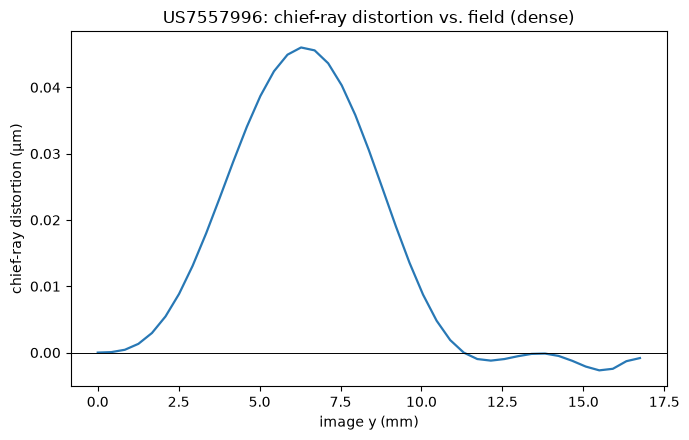

grid coverage: 96.7% of 121 points (a 50 mm half-field square grid; the design's usable field cuts off near 68-69 mm radius, so its corners at 50*sqrt(2)=70.7 mm are just beyond that and legitimately drop out)


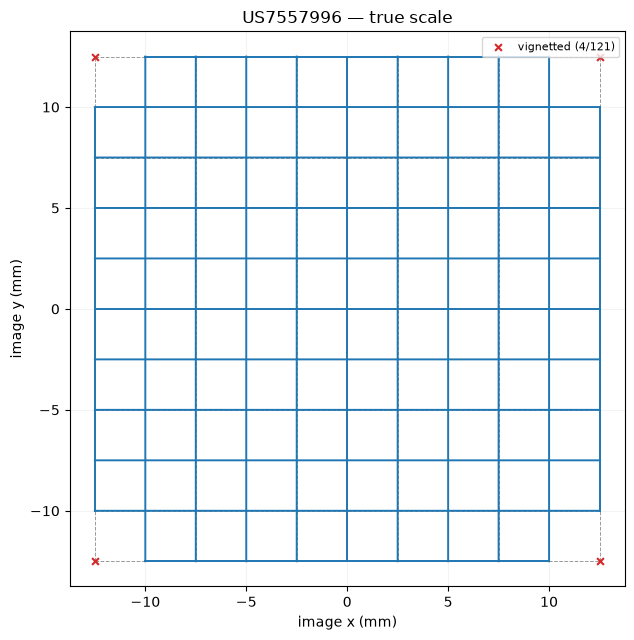

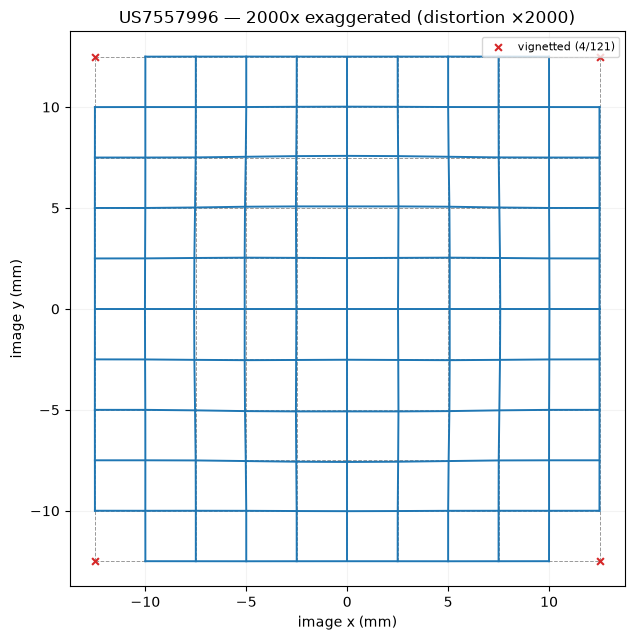

In [9]:
FIELDS_DENSE = np.linspace(0.0, 67.0, 41)
dense_metrics = field_metrics(
    tracer, FIELDS_DENSE, na_object_sine=NA_OBJECT, magnification=1.0 / REDUCTION,
)
dense_image_height = [row["centroid_image_height_mm"] for row in dense_metrics]
dense_distortion_um = [row["chief_ray_distortion_um"] for row in dense_metrics]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dense_image_height, dense_distortion_um, "-", color="#2878b5", lw=1.6)
ax.axhline(0, color="black", lw=0.7)
ax.set(xlabel="image y (mm)", ylabel="chief-ray distortion (µm)",
       title="US7557996: chief-ray distortion vs. field (dense)")
fig.tight_layout()
plt.show()

from raytracer.analysis import distortion_grid

grid = distortion_grid(tracer, magnification=1.0 / REDUCTION, half_field=50.0, n=11)
print(f"grid coverage: {grid.valid_fraction:.1%} of {grid.valid.size} points "
      f"(a 50 mm half-field square grid; the design's usable field cuts off "
      f"near 68-69 mm radius, so its corners at 50*sqrt(2)=70.7 mm are just "
      f"beyond that and legitimately drop out)")

fig = plots.distortion_grid_figure(grid, exaggeration=1.0, title="US7557996 — true scale")
plt.show()
fig = plots.distortion_grid_figure(grid, exaggeration=2000.0, title="US7557996 — 2000x exaggerated")
plt.show()

## 8 · ANSI/OSA Zernike wavefront expansion

The monochromatic wavefront is reconstructed from the exact transverse ray
aberrations through Hamilton's relation $\nabla_{\mathbf q}W=-\mathrm{NA}\,\Delta\mathbf r'$,
fitting RMS-normalized ANSI/OSA Zernike gradients through radial order 6.
Piston is unobservable from ray slopes; tilt and defocus are explicitly removable.

RMS excluding tilt: 21.0048 nm
RMS after tilt/defocus removal: 0.5089 nm
Gradient-fit residual: 0.004287 µm
ANSI  1  (1,-1)  Y tilt                              +4.018018 nm RMS
ANSI  2  (1,+1)  X tilt                              +0.000000 nm RMS
ANSI  3  (2,-2)  Oblique astigmatism                 +0.000000 nm RMS
ANSI  4  (2,+0)  Defocus                            -20.998673 nm RMS
ANSI  5  (2,+2)  Vertical astigmatism                -0.088437 nm RMS
ANSI  6  (3,-3)  Oblique trefoil                     -0.046688 nm RMS
ANSI  7  (3,-1)  Y coma                              +0.176357 nm RMS
ANSI  8  (3,+1)  X coma                              -0.000000 nm RMS
ANSI  9  (3,+3)  Vertical trefoil                    +0.000000 nm RMS
ANSI 10  (4,-4)  Oblique quadrafoil                  -0.000000 nm RMS
ANSI 11  (4,-2)  Secondary oblique astigmatism       +0.000000 nm RMS
ANSI 12  (4,+0)  Primary spherical                   -0.053739 nm RMS
ANSI 13  (4,+2)  Secondary vertical astigmatism     

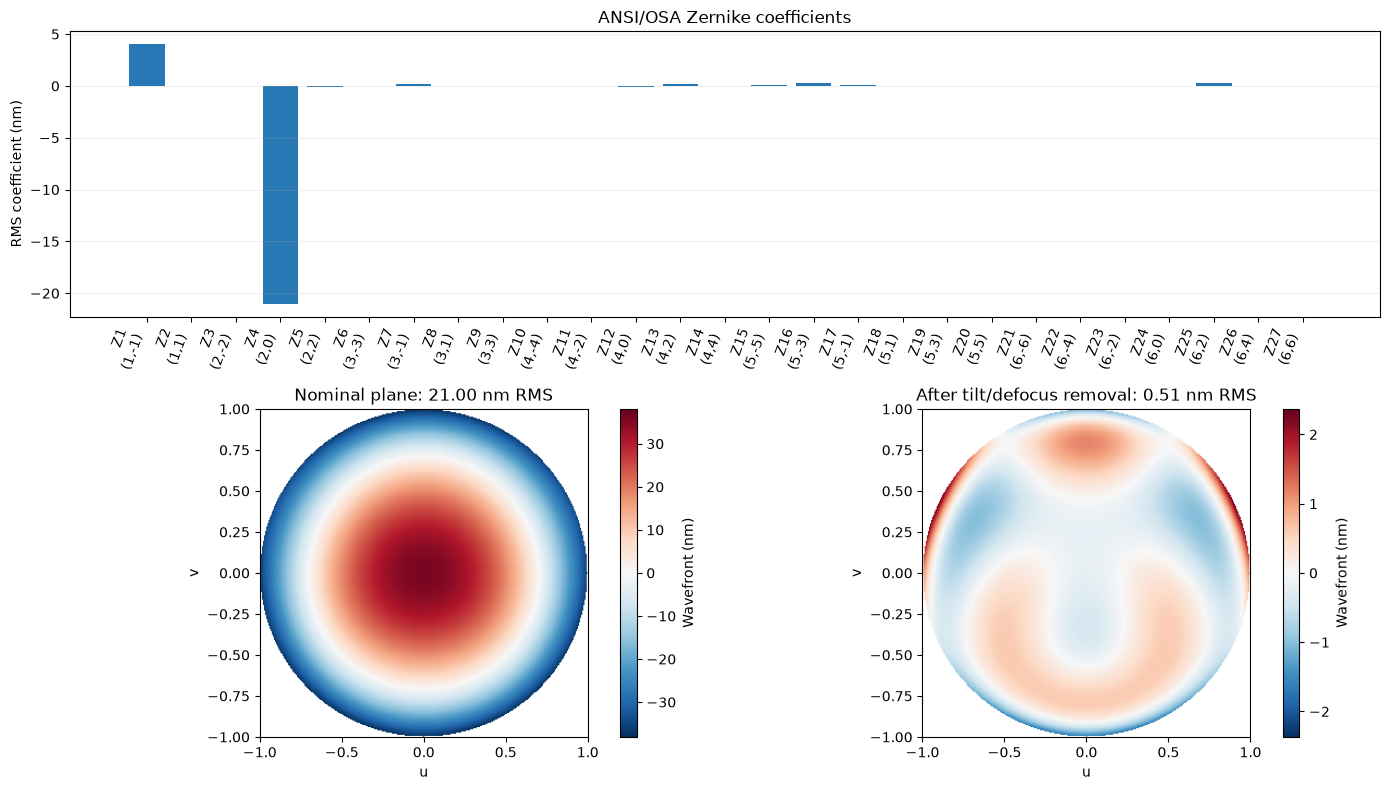

In [10]:
zpupil = trace_pupil(
    tracer, FieldPoint(y=62.0), na_object_sine=NA_OBJECT,
    sampling=PupilSampling(kind="rings", radial=12, azimuth=72),
)
zfit = fit_transverse(
    zpupil, na_image=NA_IMAGE, n_image=system.n_image,
    wavelength_mm=WAVELENGTH_MM, max_order=6,
)
zfit.export_csv("US7557996_zernike_coefficients.csv")

print(f"RMS excluding tilt: {zfit.rms_no_tilt_nm:.4f} nm")
print(f"RMS after tilt/defocus removal: {zfit.rms_refocused_nm:.4f} nm")
print(f"Gradient-fit residual: {zfit.gradient_fit_residual_um:.6f} µm")
for row in zfit.records:
    print(f"ANSI {row['ansi_index']:2d}  ({row['radial_order_n']},{row['azimuthal_frequency_m']:+d})  "
          f"{row['name']:<34s} {row['coefficient_nm_rms']:+10.6f} nm RMS")

fig = plots.zernike_figure(zfit)
fig.savefig(OUT / "zernike_wavefront.png", dpi=180); plt.show()

## 9 · Partially coherent Abbe aerial image

The fitted best-focus Zernike wavefront becomes pupil phase; a synthetic
wafer-scale mask (line/space arrays, elbows, an isolated line, contacts) is
imaged with a conventional circular source, $\sigma=0.7$, by the Abbe method.

$$r_{\rm Airy}=0.61\lambda/\mathrm{NA}=98.3\ \mathrm{nm}.$$

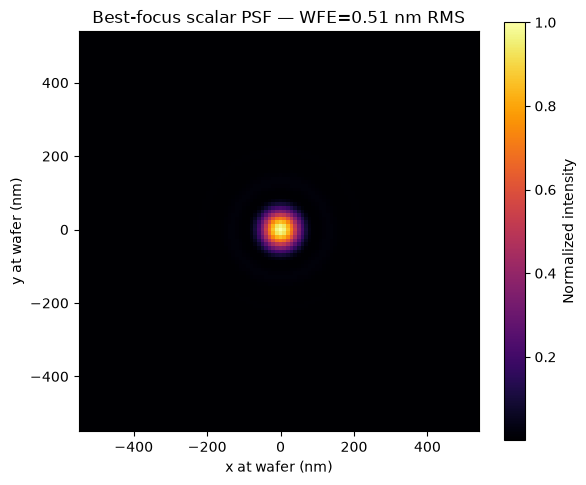

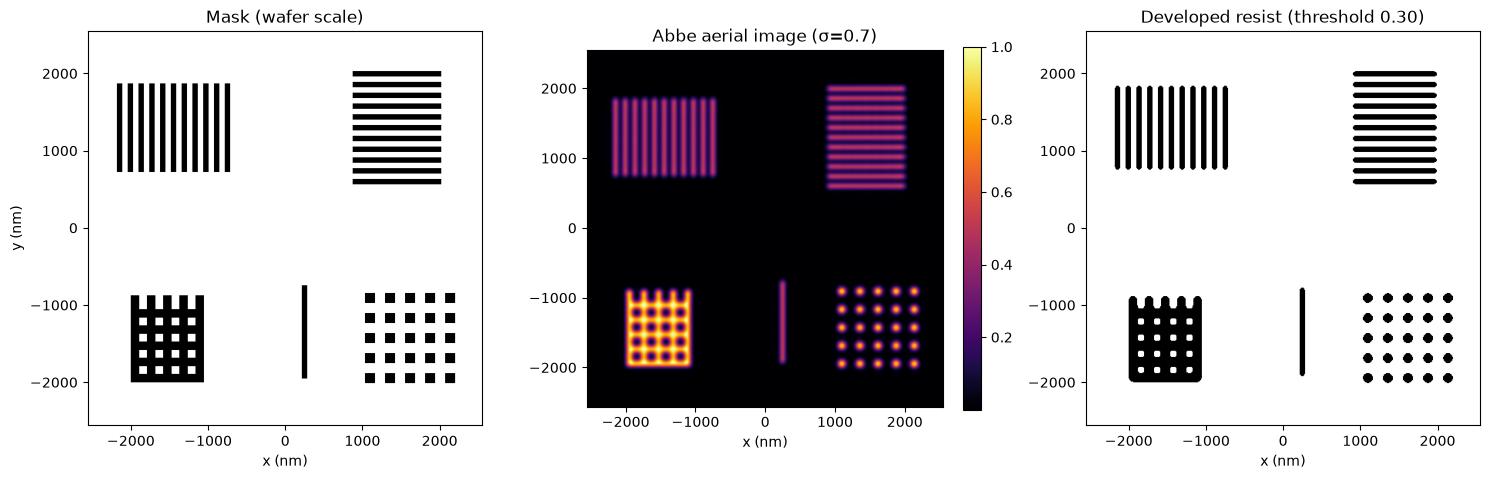

Airy radius: 98.30 nm


In [11]:
PIXEL_NM = 10.0
grid = pupil_function(
    lambda u, v: zfit.wavefront(u, v, refocus=True),
    na=NA_IMAGE, wavelength_mm=WAVELENGTH_MM, size=512, pixel_mm=PIXEL_NM * 1e-6,
)
psf = scalar_psf(grid)
fig = plots.psf_figure(
    psf, pixel_nm=PIXEL_NM, crop=55,
    title=f"Best-focus scalar PSF — WFE={zfit.rms_refocused_nm:.2f} nm RMS",
)
fig.savefig(OUT / "scalar_psf.png", dpi=180); plt.show()

mask = BinaryMask.lithography_target(size=512, pixel_nm=PIXEL_NM)
aerial = abbe_image(grid, mask, sigma=0.7, source_points=11)
fig = plots.aerial_figure(
    mask.data, aerial, pixel_nm=PIXEL_NM, threshold=0.30,
    title="Abbe aerial image (σ=0.7)",
)
fig.savefig(OUT / "aerial_image.png", dpi=180); plt.show()
print(f"Airy radius: {airy_radius_mm(NA_IMAGE, WAVELENGTH_MM) * 1e6:.2f} nm")

## 9b · Seidel-style aberration coefficients

Deduced from the exact-ray-traced wavefront (`seidel_coefficients`), the
same low-order-Zernike-to-monomial conversion used elsewhere in this
package, rather than a paraxial per-surface formula. For this
highly-corrected, 12-asphere lithographic objective, expect small
(sub-wave) coefficients throughout, consistent with the ~0.1 wave RMS
already seen in section 8 — and, since this is a modern design balanced
against 5th-order (not just Seidel/3rd-order) terms across the field,
don't expect the classical "coma grows linearly, spherical stays
constant" textbook shapes to hold as cleanly as they do for the simple
unaspherized Cooke triplet/double-Gauss examples.

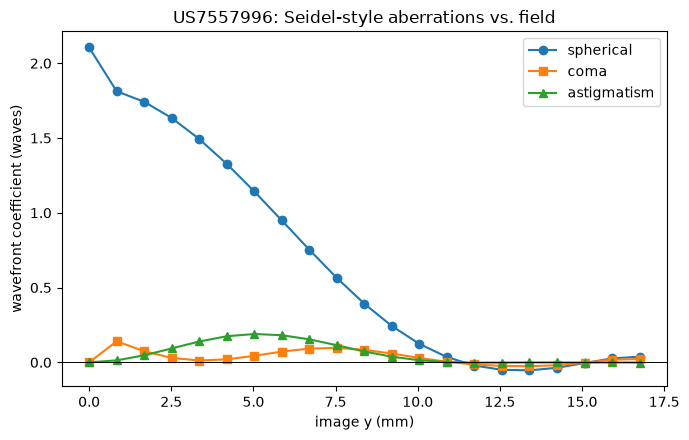

spherical (field-independent):  +0.6771 waves
coma (per unit field height):   +0.0004 waves/mm
astigmatism (per h^2):          +0.0000 waves/mm^2
field curvature (per h^2):      -0.0002 waves/mm^2
(design defocus offset:         +0.2620 waves)


In [12]:
from raytracer.analysis import seidel_coefficients

seidel_fields = np.linspace(0.0, 67.0, 21)
seidel = seidel_coefficients(
    tracer, seidel_fields, na_object_sine=NA_OBJECT, na_image=NA_IMAGE,
    wavelength_mm=WAVELENGTH_MM, n_image=system.n_image,
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(seidel_fields * (1.0 / REDUCTION), seidel.spherical_waves, "o-", label="spherical")
ax.plot(seidel_fields * (1.0 / REDUCTION), seidel.coma_waves, "s-", label="coma")
ax.plot(seidel_fields * (1.0 / REDUCTION), seidel.astigmatism_waves, "^-", label="astigmatism")
ax.axhline(0, color="black", lw=0.7)
ax.set(xlabel="image y (mm)", ylabel="wavefront coefficient (waves)",
       title="US7557996: Seidel-style aberrations vs. field")
ax.legend()
fig.tight_layout()
plt.show()

print(seidel.summary())

## 10 · Numerical summary

- The complete 48-surface patent prescription, including all 12 even aspheres, is used without refitting.
- The recovered paraxial magnification is +0.25 to numerical precision (differential and matrix methods agree).
- The traced marginal rays reach image-space NA ≈ 1.2.
- The central annular-field geometric RMS radius is ≈ 0.086 µm; EE80 ≈ 0.105 µm.
- Zernike RMS after tilt/defocus removal ≈ 0.51 nm — the design is deeply diffraction-limited.
- Chromatic aberration cannot be reconstructed: the patent supplies indices at a single wavelength.

In [13]:
from raytracer.analysis import export_metrics_csv
export_metrics_csv("US7557996_aberration_metrics.csv", metrics)
system.to_prescription("US7557996_prescription_roundtrip.csv")
print("Exports written:")
for name in ("US7557996_aberration_metrics.csv", "US7557996_zernike_coefficients.csv",
             "US7557996_prescription_roundtrip.csv"):
    print(" -", name)

Exports written:
 - US7557996_aberration_metrics.csv
 - US7557996_zernike_coefficients.csv
 - US7557996_prescription_roundtrip.csv
